# Model Tuning, Error analysis and Model interpretation

In this notebook, we aim to impove the model, tune it professionally, inspect mistakes, and prepare a stronger final model that can detect machine failures with confidence

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from src.modeling import build_model_pipeline
from src.evaluation import evaluate_classifier, evaluate_with_threshold

In [3]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
X = df.drop(columns=[
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df["Machine failure"]

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

### Model Tuning

We will use Random Forrest as it has proven to be the best model from the ones we tested

In [6]:
rf_base_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_pipeline = build_model_pipeline(rf_base_model)

In [7]:
rf_param_dist = {
    "model__n_estimators":[200,300,400,500],
    "model__max_depth": [None,5,10,15,20,25],
    "model__min_samples_split": [2,5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__max_features": ["sqrt","log2"]
}

#### Cross Validation Randomized search

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=50,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [10]:
rf_search.fit(X_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-va

In [11]:
print("Best RF score:", rf_search.best_score_)
print("Best RF params:")
rf_search.best_params_

Best RF score: 0.8836970436441212
Best RF params:


{'model__n_estimators': 500,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_features': 'log2',
 'model__max_depth': None}

In [12]:
rf_results = pd.DataFrame(rf_search.cv_results_)

cols = [
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

param_cols = [col for col in rf_results.columns if col.startswith("param_")]

rf_results[cols + param_cols].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,rank_test_score,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth
14,0.883697,0.046131,1,500,2,1,log2,None
31,0.883687,0.046154,2,500,2,1,log2,25
24,0.882347,0.048208,3,300,2,1,log2,20
36,0.882239,0.044985,4,400,2,2,sqrt,25
8,0.880761,0.044325,5,500,2,2,log2,10
6,0.879611,0.047295,6,400,5,2,log2,25
12,0.879300,0.046297,7,500,5,2,log2,10
49,0.879200,0.046434,8,500,5,2,sqrt,25
23,0.879127,0.046389,9,500,5,2,log2,None
2,0.878646,0.042738,10,200,2,1,log2,10


In [13]:
best_rf_pipeline = rf_search.best_estimator_

In [14]:
rf_tuned_results = evaluate_classifier(
    best_rf_pipeline,
    X_val,
    y_val,
    model_name="Tuned Random Forest"
)
rf_tuned_results_df=pd.DataFrame([rf_tuned_results])
rf_tuned_results_df.to_csv("../reports/day6_tuned_rfmodel_no_threshold.csv")

=====Tuned Random Forest=====
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1449
           1       0.92      0.71      0.80        51

    accuracy                           0.99      1500
   macro avg       0.96      0.85      0.90      1500
weighted avg       0.99      0.99      0.99      1500

Confusion Matrix:
[[1446    3]
 [  15   36]]


In [15]:
best_model = best_rf_pipeline
best_model_name = "Tuned Random Forest"

In [16]:
thresholds = np.arange(0.05,0.95,0.05)
thresholds_results = []
for threshold in thresholds:
    thresholds_results.append(evaluate_with_threshold(best_model,X_val,y_val,threshold,best_model_name))
    
threshold_df = pd.DataFrame(thresholds_results)
threshold_df

===== Tuned Random Forest at threshold 0.050 =====
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1449
           1       0.40      0.94      0.56        51

    accuracy                           0.95      1500
   macro avg       0.70      0.95      0.77      1500
weighted avg       0.98      0.95      0.96      1500

Confusion Matrix:
[[1377   72]
 [   3   48]]
===== Tuned Random Forest at threshold 0.100 =====
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1449
           1       0.56      0.90      0.69        51

    accuracy                           0.97      1500
   macro avg       0.78      0.94      0.84      1500
weighted avg       0.98      0.97      0.98      1500

Confusion Matrix:
[[1413   36]
 [   5   46]]
===== Tuned Random Forest at threshold 0.150 =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     

,Model,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Tuned Random Forest,0.05,0.400000,0.941176,0.561404,0.981299,0.882727
1,Tuned Random Forest,0.10,0.560976,0.901961,0.691729,0.981299,0.882727
2,Tuned Random Forest,0.15,0.721311,0.862745,0.785714,0.981299,0.882727
3,Tuned Random Forest,0.20,0.800000,0.862745,0.830189,0.981299,0.882727
4,Tuned Random Forest,0.25,0.846154,0.862745,0.854369,0.981299,0.882727
5,Tuned Random Forest,0.30,0.897959,0.862745,0.880000,0.981299,0.882727
6,Tuned Random Forest,0.35,0.913043,0.823529,0.865979,0.981299,0.882727
7,Tuned Random Forest,0.40,0.928571,0.764706,0.838710,0.981299,0.882727
8,Tuned Random Forest,0.45,0.925000,0.725490,0.813187,0.981299,0.882727
9,Tuned Random Forest,0.50,0.923077,0.705882,0.800000,0.981299,0.882727


In [29]:
best_threshold = threshold_df.sort_values(by="F1 Score",ascending=False).iloc[0]['Threshold']
threshold_df.sort_values(by="F1 Score",ascending=False).to_csv("../reports/Threshold metrics comparison.csv")


So far best model is a random forest classifier with tuned parameters and a threshold of 0.3

### Error Analysis

In [18]:
from src.feature_engineering import add_engineered_features
y_val_proba = best_model.predict_proba(X_val)[:,1]
y_val_pred = (y_val_proba >= best_threshold).astype(int)

X_val_analysis = add_engineered_features(X_test)
error_analysis_df = X_val_analysis.copy()
error_analysis_df["y_true"] = y_val.values
error_analysis_df["y_proba"] = y_val_proba
error_analysis_df["y_pred"] = y_val_pred

In [19]:
def classify_error(row):
    if row["y_true"] == 1 and row["y_pred"] == 1:
        return "True Positive"
    elif row["y_true"] == 0 and row["y_pred"] == 0:
        return "True Negative"
    elif row["y_true"] == 0 and row["y_pred"] == 1:
        return "False Positive"
    elif row["y_true"] == 1 and row["y_pred"] == 0:
        return "False Negative"

error_analysis_df["error_type"] = error_analysis_df.apply(classify_error,axis=1)
error_analysis_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_diff [K],Power [W],Torque_Wear,y_true,y_proba,y_pred,error_type
1529,L,298.1,309.0,1557,36.0,56,10.9,5869.751714,2016.0,0,0.002,0,True Negative
8572,M,297.7,308.5,1559,35.2,127,10.8,5746.685058,4470.4,0,0.000,0,True Negative
4330,L,301.5,309.8,1549,38.5,81,8.3,6245.119676,3118.5,0,0.000,0,True Negative
1502,L,298.0,308.7,1462,48.2,204,10.7,7379.433592,9832.8,0,0.000,0,True Negative
9355,L,298.3,308.9,1708,28.0,42,10.6,5008.117569,1176.0,0,0.000,0,True Negative


In [20]:
error_analysis_df["error_type"].value_counts()

error_type
True Negative     1444
True Positive       44
False Negative       7
False Positive       5
Name: count, dtype: int64

In [21]:
false_negatives = error_analysis_df[
    error_analysis_df["error_type"] == "False Negative"
].sort_values(by="y_proba", ascending=False)

false_negatives.head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_diff [K],Power [W],Torque_Wear,y_true,y_proba,y_pred,error_type
2417,L,298.9,308.3,1576,36.6,7,9.4,6040.403027,256.2,1,0.150,0,False Negative
8560,L,298.3,309.0,1408,45.4,98,10.7,6694.021850,4449.2,1,0.110,0,False Negative
3309,L,301.3,310.4,1384,50.1,88,9.1,7261.100268,4408.8,1,0.092,0,False Negative
2704,M,299.7,309.2,1608,34.4,68,9.5,5792.594198,2339.2,1,0.076,0,False Negative
38,H,298.9,309.2,1379,50.7,106,10.3,7321.513095,5374.2,1,0.032,0,False Negative
6369,H,300.0,309.5,1781,24.9,70,9.5,4643.996508,1743.0,1,0.020,0,False Negative
4633,L,303.0,311.2,1382,50.5,203,8.2,7308.496430,10251.5,1,0.000,0,False Negative


In [22]:
false_positives = error_analysis_df[
    error_analysis_df["error_type"] == "False Positive"
].sort_values(by="y_proba", ascending=False)

false_positives.head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_diff [K],Power [W],Torque_Wear,y_true,y_proba,y_pred,error_type
3320,L,301.5,310.5,2289,16.4,112,9.0,3931.137719,1836.8,0,0.850,1,False Positive
8872,M,297.9,309.1,1614,38.1,62,11.2,6439.573789,2362.2,0,0.814,1,False Positive
9932,L,298.3,308.2,1663,28.4,67,9.9,4945.830258,1902.8,0,0.672,1,False Positive
5813,L,301.2,311.0,1761,29.1,195,9.8,5366.374323,5674.5,0,0.354,1,False Positive
6974,L,300.7,311.0,1318,48.2,128,10.3,6652.594715,6169.6,0,0.336,1,False Positive


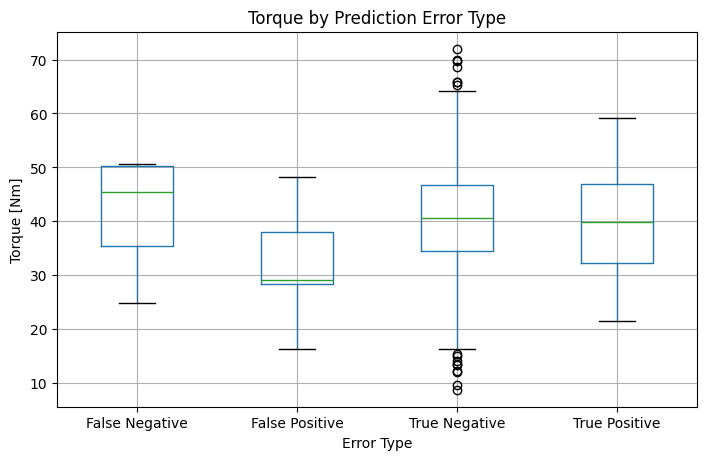

In [23]:
import matplotlib.pyplot as plt

error_analysis_df.boxplot(
    column="Torque [Nm]",
    by="error_type",
    figsize=(8, 5)
)

plt.title("Torque by Prediction Error Type")
plt.suptitle("")
plt.xlabel("Error Type")
plt.ylabel("Torque [Nm]")
plt.show()

In [24]:
error_analysis_df.groupby("error_type")[
    [
        "Tool wear [min]",
        "Torque [Nm]",
        "Rotational speed [rpm]",
        "Power [W]",
        "Temp_diff [K]",
        "Torque_Wear"
    ]
].median()

,Tool wear [min],Torque [Nm],Rotational speed [rpm],Power [W],Temp_diff [K],Torque_Wear
error_type,,,,,,
False Negative,88.0,45.4,1408.0,6694.021850,9.5,4408.8
False Positive,112.0,29.1,1663.0,5366.374323,9.9,2362.2
True Negative,110.0,40.7,1498.0,6332.461188,9.9,4069.5
True Positive,102.5,39.8,1517.0,6305.480143,10.2,4646.0


The missed failures tend to occur when the machine is under relatively high torque and high power conditions, even though tool wear is not unusually high. This suggests that the model may sometimes underestimate failure risk when the failure is driven more by operating load than by accumulated tool wear.

### Model interpretation and feature importance

In [25]:
from src.interpretation import get_feature_importance_from_pipeline

In [26]:
importance_df = get_feature_importance_from_pipeline(best_model)

importance_df.head(15)

,feature,importance
2,num__Rotational speed [rpm],0.203051
3,num__Torque [Nm],0.191355
6,num__Power [W],0.178521
4,num__Tool wear [min],0.135811
7,num__Torque_Wear,0.113970
5,num__Temp_diff [K],0.088228
0,num__Air temperature [K],0.047768
1,num__Process temperature [K],0.028892
10,cat__Type_M,0.005154
9,cat__Type_L,0.004747


### Testing with test data

In [27]:
evaluate_with_threshold(
    best_model,
    X_test,
    y_test,
    threshold=best_threshold,
    model_name=f"Final {best_model_name}"
)

===== Final Tuned Random Forest at threshold 0.300 =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1449
           1       0.91      0.84      0.88        51

    accuracy                           0.99      1500
   macro avg       0.95      0.92      0.94      1500
weighted avg       0.99      0.99      0.99      1500

Confusion Matrix:
[[1445    4]
 [   8   43]]


{'Model': 'Final Tuned Random Forest',
 'Threshold': np.float64(0.3),
 'Precision': 0.9148936170212766,
 'Recall': 0.8431372549019608,
 'F1 Score': 0.8775510204081632,
 'ROC-AUC': 0.9889781999756424,
 'PR-AUC': 0.9079871816065002}

The final model was evaluated once on the held-out test set after model selection and threshold tuning were completed using the validation set.

This gives a more honest estimate of how the model may perform on unseen data.

### Saving best model pipeline

In [28]:
from pathlib import Path
import joblib

models_dir = Path("../models")

joblib.dump(
    best_model,
    models_dir / "final_model_pipeline.pkl"
)
final_config = {
    "model_name": best_model_name,
    "threshold": best_threshold
}

joblib.dump(
    final_config,
    models_dir / "final_model_config.pkl"
)

['..\\models\\final_model_config.pkl']

## Day 6 Summary

In Day 6, I improved the predictive maintenance model by tuning tree-based classifiers using cross-validation. The tuned models were evaluated on the validation set using metrics suitable for imbalanced classification, especially PR-AUC and recall.

After selecting the best model, I tuned the classification threshold to reflect the business goal of reducing missed machine failures. I also performed error analysis by inspecting false positives and false negatives.

Finally, I extracted feature importances from the fitted pipeline and saved the final model pipeline for future inference.